In [9]:
# !pip install pandas numpy matplotlib

import numpy as np
import pandas as pd
import sqlite3
import os

print("套件載入成功！")

套件載入成功！


In [10]:
# ===== 牛仔褲生產模擬參數 =====

n_subgroups = 40            # 共40批
subgroup_size = 5           # 每批抽5件
target_mean = 32          # 腰圍目標值 (cm)
normal_std = 0.3            # 正常製程標準差

abnormal_batches = [15, 16, 17, 32, 33]
shift_amount = 1

print(f"模擬設定完成：{n_subgroups}批 × {subgroup_size}件 = {n_subgroups * subgroup_size}件")

模擬設定完成：40批 × 5件 = 200件


In [11]:
records = []

for batch in range(1, n_subgroups + 1):
    
    # 判斷這批是否異常
    if batch in abnormal_batches:
        mean = target_mean + shift_amount
        note = "異常：均值偏移"
    else:
        mean = target_mean
        note = "正常"
    
    # 產生這批的5個量測值
    measurements = np.random.normal(loc=mean, scale=normal_std, size=subgroup_size)
    
    for i, value in enumerate(measurements):
        records.append({
            "batch_id":    batch,
            "sample_no":   i + 1,
            "waist_cm":    round(value, 2),
            "batch_status": note
        })

df = pd.DataFrame(records)
print(f"資料筆數：{len(df)}")
print(df.head(10))

資料筆數：200
   batch_id  sample_no  waist_cm batch_status
0         1          1     32.50           正常
1         1          2     31.89           正常
2         1          3     32.60           正常
3         1          4     31.84           正常
4         1          5     32.30           正常
5         2          1     32.19           正常
6         2          2     31.93           正常
7         2          3     32.47           正常
8         2          4     32.30           正常
9         2          5     32.17           正常


In [12]:
# 建立資料庫檔案
db_path = "jeans_production.db"
conn = sqlite3.connect(db_path)

# 把 DataFrame 存入資料庫的 measurements 資料表
df.to_sql("measurements", conn, if_exists="replace", index=False)

conn.commit()
conn.close()

print(f"資料庫已建立：{db_path}")
print(f"檔案大小：{os.path.getsize(db_path) / 1024:.1f} KB")

資料庫已建立：jeans_production.db
檔案大小：16.0 KB


In [13]:
import sqlite3
import pandas as pd
import numpy as np

conn = sqlite3.connect("jeans_production.db")
df = pd.read_sql("SELECT * FROM measurements", conn)
conn.close()

# 每批計算：平均值、全距、標準差
subgroup_stats = df.groupby("batch_id")["waist_cm"].agg(
    xbar  = "mean",
    R     = lambda x: x.max() - x.min(),
    S     = "std"
).reset_index()

subgroup_stats["xbar"] = subgroup_stats["xbar"].round(4)
subgroup_stats["R"]    = subgroup_stats["R"].round(4)
subgroup_stats["S"]    = subgroup_stats["S"].round(4)

print(subgroup_stats.head(10))

   batch_id    xbar     R       S
0         1  32.226  0.76  0.3472
1         2  32.212  0.54  0.1975
2         3  32.146  1.34  0.6122
3         4  31.874  0.69  0.2678
4         5  32.136  0.68  0.2496
5         6  32.052  1.06  0.4086
6         7  31.930  1.07  0.3974
7         8  32.034  1.04  0.4357
8         9  32.148  0.45  0.2015
9        10  31.982  0.59  0.2284


In [14]:
# n=5 的管制圖常數（教科書附表）
n  = 5
A2 = 0.577
D3 = 0.0
D4 = 2.114
B3 = 0.0
B4 = 2.089
c4 = 0.9400

# 計算總平均
X_double_bar = subgroup_stats["xbar"].mean()
R_bar        = subgroup_stats["R"].mean()
S_bar        = subgroup_stats["S"].mean()

# X̄-R Chart 界限
UCL_xbar_R = X_double_bar + A2 * R_bar
LCL_xbar_R = X_double_bar - A2 * R_bar
UCL_R      = D4 * R_bar
LCL_R      = D3 * R_bar

# X̄-S Chart 界限
A3         = 3 / (c4 * np.sqrt(n))
UCL_xbar_S = X_double_bar + A3 * S_bar
LCL_xbar_S = X_double_bar - A3 * S_bar
UCL_S      = B4 * S_bar
LCL_S      = B3 * S_bar

print("========== X̄-R Chart ==========")
print(f"X̄  總平均：{X_double_bar:.4f}")
print(f"R̄  全距均值：{R_bar:.4f}")
print(f"UCL(X̄)：{UCL_xbar_R:.4f}")
print(f"LCL(X̄)：{LCL_xbar_R:.4f}")
print(f"UCL(R)：{UCL_R:.4f}")
print(f"LCL(R)：{LCL_R:.4f}")

print("\n========== X̄-S Chart ==========")
print(f"S̄  標準差均值：{S_bar:.4f}")
print(f"UCL(X̄)：{UCL_xbar_S:.4f}")
print(f"LCL(X̄)：{LCL_xbar_S:.4f}")
print(f"UCL(S)：{UCL_S:.4f}")
print(f"LCL(S)：{LCL_S:.4f}")

========== X̄-R Chart ==========
X̄  總平均：32.1431
R̄  全距均值：0.7110
UCL(X̄)：32.5533
LCL(X̄)：31.7329
UCL(R)：1.5031
LCL(R)：0.0000

========== X̄-S Chart ==========
S̄  標準差均值：0.2822
UCL(X̄)：32.5459
LCL(X̄)：31.7403
UCL(S)：0.5895
LCL(S)：0.0000


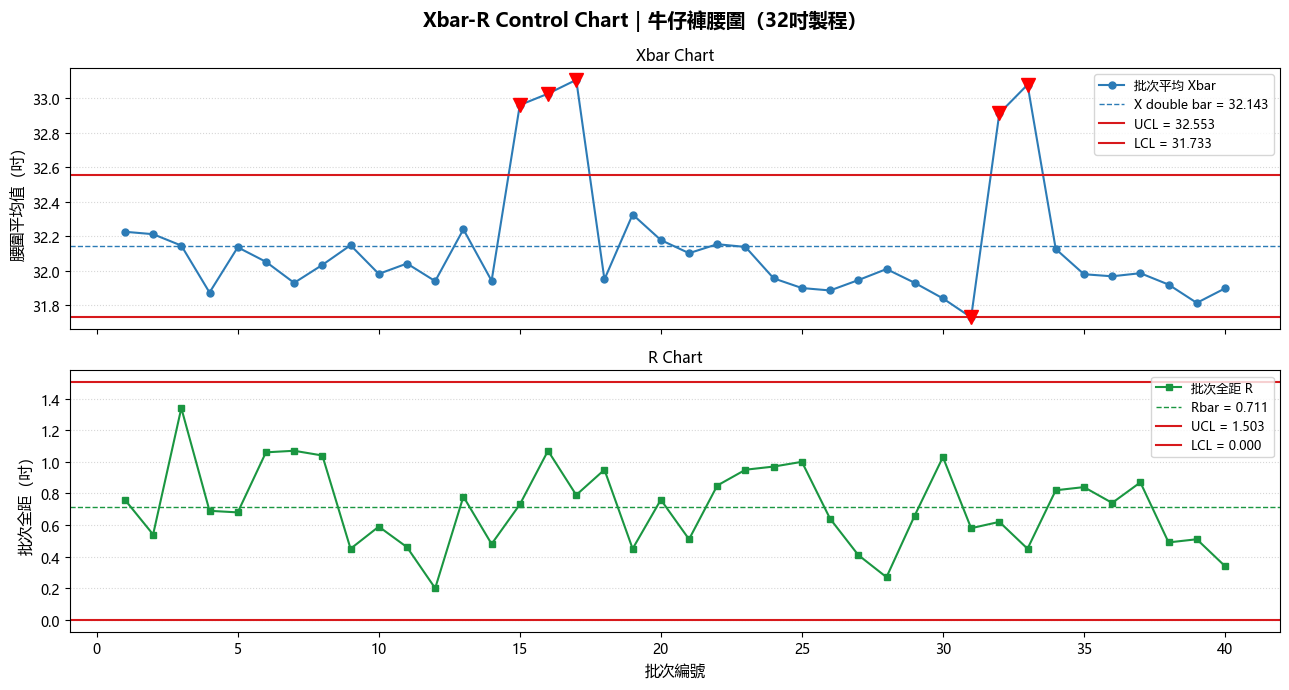

超出管制界限的批次 (X̄)：[15, 16, 17, 31, 32, 33]
超出管制界限的批次 (R)：[]


In [15]:
import matplotlib.pyplot as plt
import matplotlib
import platform
system = platform.system()

if system == "Windows":
    matplotlib.rcParams['font.family'] = 'Microsoft YaHei'
elif system == "Darwin":  # Mac
    matplotlib.rcParams['font.family'] = 'Arial Unicode MS'
else:  # Linux 或其他
    matplotlib.rcParams['font.family'] = 'DejaVu Sans'

matplotlib.rcParams['axes.unicode_minus'] = False
# 標記哪些點超出管制界限
def mark_ooc(values, ucl, lcl):
    return [i+1 for i, v in enumerate(values) if v > ucl or v < lcl]

ooc_xbar_R = mark_ooc(subgroup_stats["xbar"], UCL_xbar_R, LCL_xbar_R)
ooc_R      = mark_ooc(subgroup_stats["R"],    UCL_R,      LCL_R)

batches = subgroup_stats["batch_id"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
fig.suptitle("Xbar-R Control Chart｜牛仔褲腰圍（32吋製程）", fontsize=14, fontweight="bold", y=0.98)

# --- 上圖：X̄ chart ---
ax1.plot(batches, subgroup_stats["xbar"], color="#2c7bb6", marker="o",
         markersize=5, linewidth=1.5, label="批次平均 Xbar")
ax1.axhline(X_double_bar, color="#2c7bb6", linestyle="--", linewidth=1, label=f"X double bar = {X_double_bar:.3f}")
ax1.axhline(UCL_xbar_R,   color="#d7191c", linestyle="-",  linewidth=1.5, label=f"UCL = {UCL_xbar_R:.3f}")
ax1.axhline(LCL_xbar_R,   color="#d7191c", linestyle="-",  linewidth=1.5, label=f"LCL = {LCL_xbar_R:.3f}")

for b in ooc_xbar_R:
    ax1.plot(b, subgroup_stats.loc[subgroup_stats["batch_id"]==b, "xbar"].values[0],
             "rv", markersize=10, zorder=5)

ax1.set_ylabel("腰圍平均值（吋）", fontsize=11)
ax1.legend(loc="upper right", fontsize=9)
ax1.set_title("Xbar Chart", fontsize=11)
ax1.grid(axis="y", linestyle=":", alpha=0.5)

# --- 下圖：R chart ---
ax2.plot(batches, subgroup_stats["R"], color="#1a9641", marker="s",
         markersize=5, linewidth=1.5, label="批次全距 R")
ax2.axhline(R_bar,   color="#1a9641", linestyle="--", linewidth=1, label=f"Rbar = {R_bar:.3f}")
ax2.axhline(UCL_R,   color="#d7191c", linestyle="-",  linewidth=1.5, label=f"UCL = {UCL_R:.3f}")
ax2.axhline(LCL_R,   color="#d7191c", linestyle="-",  linewidth=1.5, label=f"LCL = {LCL_R:.3f}")

for b in ooc_R:
    ax2.plot(b, subgroup_stats.loc[subgroup_stats["batch_id"]==b, "R"].values[0],
             "rv", markersize=10, zorder=5)

ax2.set_ylabel("批次全距（吋）", fontsize=11)
ax2.set_xlabel("批次編號", fontsize=11)
ax2.legend(loc="upper right", fontsize=9)
ax2.set_title("R Chart", fontsize=11)
ax2.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig("xbar_R_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"超出管制界限的批次 (X̄)：{ooc_xbar_R}")
print(f"超出管制界限的批次 (R)：{ooc_R}")

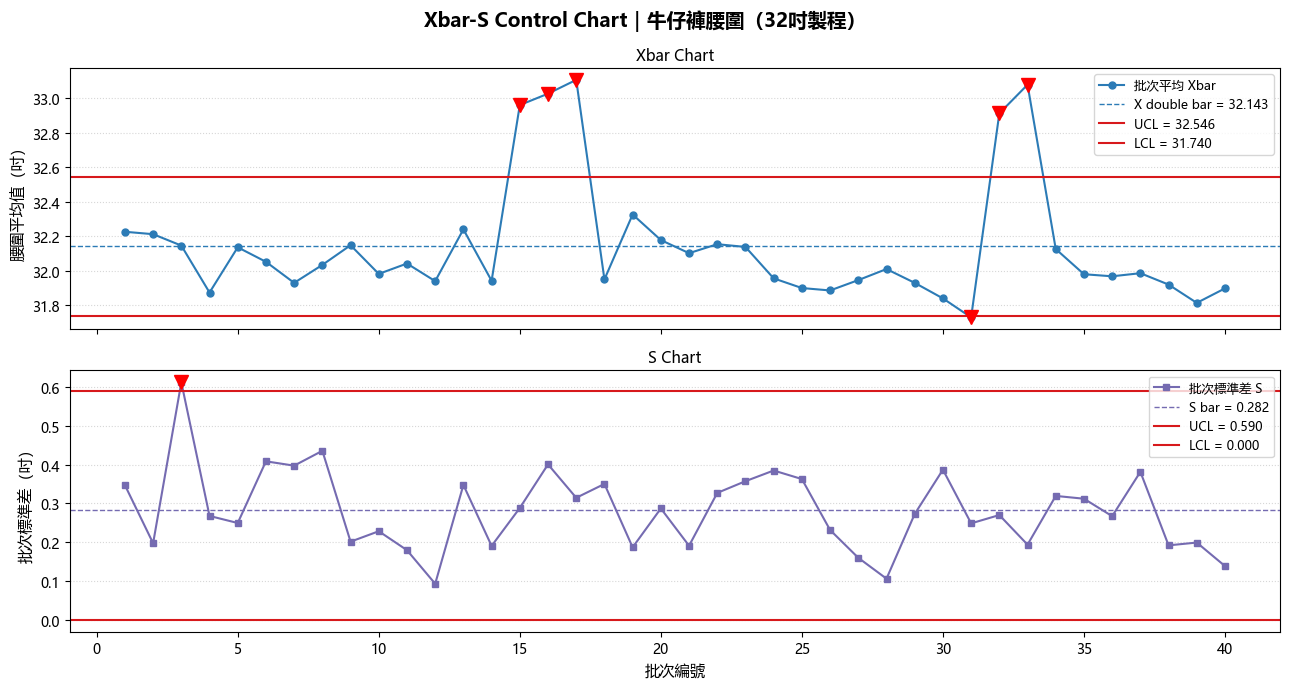

超出管制界限的批次 (X̄)：[15, 16, 17, 31, 32, 33]
超出管制界限的批次 (S)：[3]


In [16]:
ooc_xbar_S = mark_ooc(subgroup_stats["xbar"], UCL_xbar_S, LCL_xbar_S)
ooc_S      = mark_ooc(subgroup_stats["S"],    UCL_S,      LCL_S)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
fig.suptitle("Xbar-S Control Chart｜牛仔褲腰圍（32吋製程）", fontsize=14, fontweight="bold", y=0.98)

# --- 上圖：X̄ chart ---
ax1.plot(batches, subgroup_stats["xbar"], color="#2c7bb6", marker="o",
         markersize=5, linewidth=1.5, label="批次平均 Xbar")
ax1.axhline(X_double_bar, color="#2c7bb6", linestyle="--", linewidth=1, label=f"X double bar = {X_double_bar:.3f}")
ax1.axhline(UCL_xbar_S,   color="#d7191c", linestyle="-",  linewidth=1.5, label=f"UCL = {UCL_xbar_S:.3f}")
ax1.axhline(LCL_xbar_S,   color="#d7191c", linestyle="-",  linewidth=1.5, label=f"LCL = {LCL_xbar_S:.3f}")

for b in ooc_xbar_S:
    ax1.plot(b, subgroup_stats.loc[subgroup_stats["batch_id"]==b, "xbar"].values[0],
             "rv", markersize=10, zorder=5)

ax1.set_ylabel("腰圍平均值（吋）", fontsize=11)
ax1.legend(loc="upper right", fontsize=9)
ax1.set_title("Xbar Chart", fontsize=11)
ax1.grid(axis="y", linestyle=":", alpha=0.5)

# --- 下圖：S chart ---
ax2.plot(batches, subgroup_stats["S"], color="#756bb1", marker="s",
         markersize=5, linewidth=1.5, label="批次標準差 S")
ax2.axhline(S_bar,   color="#756bb1", linestyle="--", linewidth=1, label=f"S bar = {S_bar:.3f}")
ax2.axhline(UCL_S,   color="#d7191c", linestyle="-",  linewidth=1.5, label=f"UCL = {UCL_S:.3f}")
ax2.axhline(LCL_S,   color="#d7191c", linestyle="-",  linewidth=1.5, label=f"LCL = {LCL_S:.3f}")

for b in ooc_S:
    ax2.plot(b, subgroup_stats.loc[subgroup_stats["batch_id"]==b, "S"].values[0],
             "rv", markersize=10, zorder=5)

ax2.set_ylabel("批次標準差（吋）", fontsize=11)
ax2.set_xlabel("批次編號", fontsize=11)
ax2.legend(loc="upper right", fontsize=9)
ax2.set_title("S Chart", fontsize=11)
ax2.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig("xbar_S_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"超出管制界限的批次 (X̄)：{ooc_xbar_S}")
print(f"超出管制界限的批次 (S)：{ooc_S}")

In [17]:
import os, sys

# ── 環境檢查：Binder / 無桌面環境不執行 tkinter GUI ──
_has_display = bool(os.environ.get('DISPLAY') or os.environ.get('WAYLAND_DISPLAY') or sys.platform == 'darwin' or sys.platform == 'win32')

if not _has_display:
    print('⚠️  偵測到無桌面顯示器環境（例如 Binder），跳過 tkinter GUI。')
    print('   若要使用互動式 GUI，請在本地電腦執行此 Notebook。')
else:
    # ── 以下為 tkinter GUI 程式碼 ────────────────────────────────
    import tkinter as tk
    from tkinter import ttk, scrolledtext
    import matplotlib.pyplot as plt
    from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
    import numpy as np
    import pandas as pd
    import sqlite3
    
    # ── Cross-platform fonts ──────────────────────────────────────────
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "Arial", "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False
    
    ABNORMAL_BATCHES_BASE = [15, 16, 17, 32, 33]
    
    # ── Colors ───────────────────────────────────────────────────────
    CLR = {
        "navy":    "#2c3e50",
        "panel":   "#34495e",
        "teal":    "#0d7377",
        "blue":    "#2c7bb6",
        "green":   "#1a9641",
        "purple":  "#756bb1",
        "red":     "#d7191c",
        "bg":      "#f4f6f8",
        "white":   "#ffffff",
        "gray":    "#8896a5",
        "lgray":   "#dee5ed",
    }
    
    # ── Shared helpers ────────────────────────────────────────────────
    def generate_data(mean, std, shift, n, subgroups):
        abnormal = [b for b in ABNORMAL_BATCHES_BASE if b <= subgroups]
        records = []
        for b in range(1, subgroups + 1):
            m = mean + shift if b in abnormal else mean
            vals = np.random.normal(m, std, n)
            for v in vals:
                records.append({"batch": b, "value": round(v, 4)})
        return pd.DataFrame(records), abnormal
    
    def save_to_db(df, table="measurements"):
        conn = sqlite3.connect("jeans_production.db")
        df.to_sql(table, conn, if_exists="replace", index=False)
        conn.commit()
        conn.close()
    
    def get_ooc(values, ucl, lcl):
        return [i + 1 for i, v in enumerate(values) if v > ucl or v < lcl]
    
    def add_limit_labels(ax, x_end, pairs):
        """Draw value labels to the right of the control lines."""
        for val, label, color in pairs:
            ax.text(x_end + 0.4, val, label, color=color,
                    fontsize=8, va="center")
    
    # ── Styling helpers ───────────────────────────────────────────────
    def make_title_bar(parent, text):
        tk.Label(parent, text=text,
                 font=("Arial", 14, "bold"),
                 bg=CLR["navy"], fg=CLR["white"],
                 pady=9).pack(fill="x")
    
    def make_section_label(parent, text):
        tk.Label(parent, text=text,
                 font=("Arial", 9, "bold"),
                 bg=CLR["panel"], fg=CLR["white"],
                 pady=4).pack(fill="x")
    
    def make_slider(parent, label, var, from_, to_, resolution,
                    default, value_color, callback):
        """One labeled slider with a live value readout."""
        row = tk.Frame(parent, bg=CLR["white"])
        row.pack(fill="x", padx=10, pady=(4, 0))
    
        tk.Label(row, text=label, font=("Arial", 9),
                 bg=CLR["white"], anchor="w").pack(side="left")
    
        val_lbl = tk.Label(row, text=f"{default:.2f}" if isinstance(default, float) else str(default),
                           font=("Courier", 9, "bold"),
                           bg=CLR["white"], fg=value_color, width=6, anchor="e")
        val_lbl.pack(side="right")
    
        def on_change(v):
            try:
                val = float(v)
                val_lbl.config(text=f"{val:.2f}" if resolution < 1 else str(int(val)))
            except Exception:
                pass
            callback()
    
        scale = tk.Scale(parent, from_=from_, to=to_, resolution=resolution,
                         orient="horizontal", variable=var,
                         command=on_change,
                         bg=CLR["white"], troughcolor=CLR["lgray"],
                         highlightthickness=0, bd=0,
                         sliderlength=14, sliderrelief="flat")
        scale.pack(fill="x", padx=10, pady=(0, 4))
        return val_lbl
    
    def make_info_box(parent, title):
        tk.Label(parent, text=title,
                 font=("Arial", 9, "bold"),
                 bg=CLR["panel"], fg=CLR["white"],
                 pady=4).pack(fill="x")
        txt = scrolledtext.ScrolledText(parent, height=5,
                                        font=("Courier", 9),
                                        state="disabled",
                                        bg="#fafafa")
        txt.pack(fill="x", padx=4, pady=4)
        return txt
    
    def write_info(widget, text):
        widget.configure(state="normal")
        widget.delete("1.0", tk.END)
        widget.insert(tk.END, text)
        widget.configure(state="disabled")
    
    # ── X-bar R Chart Window ──────────────────────────────────────────
    def open_xr_window():
        win = tk.Toplevel()
        win.title("X-bar & R Control Chart")
        win.configure(bg=CLR["bg"])
    
        make_title_bar(win, "X-bar & R Control Chart  |  Jeans Waist (inch)")
    
        body = tk.Frame(win, bg=CLR["bg"])
        body.pack(fill="both", expand=True, padx=8, pady=8)
    
        # ── Left panel ──
        left = tk.Frame(body, bg=CLR["white"],
                        relief="groove", bd=1, width=220)
        left.pack(side="left", fill="y", padx=(0, 8))
        left.pack_propagate(False)
    
        make_section_label(left, "  Process Parameters")
    
        mean_v  = tk.DoubleVar(value=32.0)
        std_v   = tk.DoubleVar(value=0.3)
        shift_v = tk.DoubleVar(value=1.0)
        n_v     = tk.IntVar(value=4)
        sub_v   = tk.IntVar(value=22)
    
        def refresh(*_):
            _update_xr(mean_v, std_v, shift_v, n_v, sub_v,
                       fig, canvas, info_txt, db_lbl)
    
        make_slider(left, "Process Mean (in)",   mean_v,  30.0, 34.0, 0.1,  32.0, CLR["blue"],   refresh)
        make_slider(left, "Std Deviation (in)",  std_v,    0.1,  1.0, 0.05,  0.3, CLR["blue"],   refresh)
        make_slider(left, "Shift Amount (in)",   shift_v,  0.0,  3.0, 0.1,   1.0, CLR["red"],    refresh)
    
        ttk.Separator(left, orient="horizontal").pack(fill="x", pady=6)
        make_section_label(left, "  Database Settings")
    
        make_slider(left, "Subgroup size (n)",   n_v,    3,   5, 1,    4, CLR["teal"],   refresh)
        make_slider(left, "No. of Subgroups",    sub_v, 20,  40, 1,   22, CLR["purple"], refresh)
    
        ttk.Separator(left, orient="horizontal").pack(fill="x", pady=6)
        make_section_label(left, "  Database Info")
    
        db_lbl = tk.Label(left,
                          text="", font=("Courier", 8),
                          bg=CLR["white"], fg="#444",
                          justify="left", anchor="nw")
        db_lbl.pack(fill="x", padx=10, pady=4)
    
        # ── Right panel ──
        right = tk.Frame(body, bg=CLR["bg"])
        right.pack(side="left", fill="both", expand=True)
    
        fig = plt.Figure(figsize=(8.5, 5.5), tight_layout=True)
        canvas = FigureCanvasTkAgg(fig, master=right)
        canvas.get_tk_widget().pack(fill="both", expand=True)
    
        info_frame = tk.Frame(right, bg=CLR["white"],
                              relief="groove", bd=1)
        info_frame.pack(fill="x", pady=(6, 0))
        info_txt = make_info_box(info_frame, "  Control Limits & Out-of-Control Subgroups")
    
        refresh()
    
    
    def _update_xr(mean_v, std_v, shift_v, n_v, sub_v,
                   fig, canvas, info_txt, db_lbl):
        mean = mean_v.get()
        std  = std_v.get()
        shft = shift_v.get()
        n    = int(n_v.get())
        sub  = int(sub_v.get())
    
        A2 = {3: 1.023, 4: 0.729, 5: 0.577}.get(n, 0.577)
        D3 = {3: 0,     4: 0,     5: 0    }.get(n, 0)
        D4 = {3: 2.574, 4: 2.282, 5: 2.114}.get(n, 2.114)
    
        df, abnormal = generate_data(mean, std, shft, n, sub)
        save_to_db(df)
    
        stats = df.groupby("batch")["value"].agg(
            xbar="mean",
            R=lambda x: x.max() - x.min()
        ).reset_index()
    
        xbar_bar = stats["xbar"].mean()
        R_bar    = stats["R"].mean()
        UCLx, LCLx = xbar_bar + A2 * R_bar, xbar_bar - A2 * R_bar
        UCLR, LCLR = D4 * R_bar, D3 * R_bar
    
        ooc_x = get_ooc(stats["xbar"], UCLx, LCLx)
        ooc_r = get_ooc(stats["R"],    UCLR, LCLR)
    
        # ── Plot ──
        fig.clf()
        ax1, ax2 = fig.subplots(2, 1, sharex=True)
        fig.suptitle("X-bar & R Control Chart  |  Jeans Waist Process Monitoring",
                     fontsize=12, fontweight="bold")
    
        x_end = sub + 0.5
    
        # X-bar chart
        ax1.plot(stats["batch"], stats["xbar"], "o-",
                 color=CLR["blue"], markersize=4, linewidth=1.5, label="Subgroup Mean")
        ax1.axhline(xbar_bar, linestyle="--", color=CLR["blue"], linewidth=1)
        ax1.axhline(UCLx, color=CLR["red"], linewidth=1.5)
        ax1.axhline(LCLx, color=CLR["red"], linewidth=1.5)
        for b in ooc_x:
            ax1.plot(b, stats.loc[stats["batch"] == b, "xbar"].values[0],
                     "rv", markersize=9, zorder=5)
        add_limit_labels(ax1, x_end, [
            (UCLx,     f"UCL={UCLx:.3f}",     CLR["red"]),
            (xbar_bar, f"CL ={xbar_bar:.3f}", CLR["blue"]),
            (LCLx,     f"LCL={LCLx:.3f}",     CLR["red"]),
        ])
        ax1.set_xlim(left=0.5, right=x_end + 1.5)
        ax1.set_ylabel("Mean Waist (in)")
        ax1.set_title("X-bar Chart")
        ax1.grid(axis="y", linestyle=":", alpha=0.5)
        ax1.legend(fontsize=8, loc="upper left")
    
        # R chart
        ax2.plot(stats["batch"], stats["R"], "s-",
                 color=CLR["green"], markersize=4, linewidth=1.5, label="Subgroup Range")
        ax2.axhline(R_bar, linestyle="--", color=CLR["green"], linewidth=1)
        ax2.axhline(UCLR, color=CLR["red"], linewidth=1.5)
        ax2.axhline(LCLR, color=CLR["red"], linewidth=1.5)
        for b in ooc_r:
            ax2.plot(b, stats.loc[stats["batch"] == b, "R"].values[0],
                     "rv", markersize=9, zorder=5)
        add_limit_labels(ax2, x_end, [
            (UCLR,  f"UCL={UCLR:.3f}",  CLR["red"]),
            (R_bar, f"CL ={R_bar:.3f}", CLR["green"]),
            (LCLR,  f"LCL={LCLR:.3f}",  CLR["red"]),
        ])
        ax2.set_xlim(left=0.5, right=x_end + 1.5)
        ax2.set_ylabel("Subgroup Range (in)")
        ax2.set_xlabel("Subgroup Number")
        ax2.set_title("R Chart")
        ax2.grid(axis="y", linestyle=":", alpha=0.5)
        ax2.legend(fontsize=8, loc="upper left")
    
        canvas.draw()
    
        # Database info
        abn_str = ", ".join(str(b) for b in abnormal) if abnormal else "None"
        db_lbl.config(
            text=(f"Total Units   : {n * sub}\n"
                  f"Subgroups     : {sub}\n"
                  f"Subgroup size : n = {n}\n"
                  f"OOC subgroups :\n  {abn_str}")
        )
    
        write_info(info_txt,
            f"[ X-bar & R Chart Control Limits ]\n"
            f"  X-bar  UCL={UCLx:.4f}  CL={xbar_bar:.4f}  LCL={LCLx:.4f}\n"
            f"  R      UCL={UCLR:.4f}  CL={R_bar:.4f}  LCL={LCLR:.4f}\n\n"
            f"  Out-of-Control (X-bar) : {ooc_x}\n"
            f"  Out-of-Control (R)     : {ooc_r}\n"
        )
    
    
    # ── X-bar S Chart Window ──────────────────────────────────────────
    def open_xs_window():
        win = tk.Toplevel()
        win.title("X-bar & S Control Chart")
        win.configure(bg=CLR["bg"])
    
        make_title_bar(win, "X-bar & S Control Chart  |  Jeans Waist (inch)")
    
        body = tk.Frame(win, bg=CLR["bg"])
        body.pack(fill="both", expand=True, padx=8, pady=8)
    
        # ── Left panel ──
        left = tk.Frame(body, bg=CLR["white"],
                        relief="groove", bd=1, width=220)
        left.pack(side="left", fill="y", padx=(0, 8))
        left.pack_propagate(False)
    
        make_section_label(left, "  Process Parameters")
    
        mean_v  = tk.DoubleVar(value=32.0)
        std_v   = tk.DoubleVar(value=0.3)
        shift_v = tk.DoubleVar(value=1.0)
        n_v     = tk.IntVar(value=12)
        sub_v   = tk.IntVar(value=40)
    
        def refresh(*_):
            _update_xs(mean_v, std_v, shift_v, n_v, sub_v,
                       fig, canvas, info_txt, db_lbl)
    
        make_slider(left, "Process Mean (in)",   mean_v,  30.0, 34.0, 0.1,  32.0, CLR["blue"],   refresh)
        make_slider(left, "Std Deviation (in)",  std_v,    0.1,  1.0, 0.05,  0.3, CLR["blue"],   refresh)
        make_slider(left, "Shift Amount (in)",   shift_v,  0.0,  3.0, 0.1,   1.0, CLR["red"],    refresh)
    
        ttk.Separator(left, orient="horizontal").pack(fill="x", pady=6)
        make_section_label(left, "  Database Settings")
    
        make_slider(left, "Subgroup size (n>10)", n_v,  10, 30, 1,  12, CLR["teal"],   refresh)
        make_slider(left, "No. of Subgroups",     sub_v, 20, 60, 1,  40, CLR["purple"], refresh)
    
        ttk.Separator(left, orient="horizontal").pack(fill="x", pady=6)
        make_section_label(left, "  Database Info")
    
        db_lbl = tk.Label(left,
                          text="", font=("Courier", 8),
                          bg=CLR["white"], fg="#444",
                          justify="left", anchor="nw")
        db_lbl.pack(fill="x", padx=10, pady=4)
    
        # ── Right panel ──
        right = tk.Frame(body, bg=CLR["bg"])
        right.pack(side="left", fill="both", expand=True)
    
        fig = plt.Figure(figsize=(8.5, 5.5), tight_layout=True)
        canvas = FigureCanvasTkAgg(fig, master=right)
        canvas.get_tk_widget().pack(fill="both", expand=True)
    
        info_frame = tk.Frame(right, bg=CLR["white"],
                              relief="groove", bd=1)
        info_frame.pack(fill="x", pady=(6, 0))
        info_txt = make_info_box(info_frame, "  Control Limits & Out-of-Control Subgroups")
    
        refresh()
    
    
    def _update_xs(mean_v, std_v, shift_v, n_v, sub_v,
                   fig, canvas, info_txt, db_lbl):
        mean = mean_v.get()
        std  = std_v.get()
        shft = shift_v.get()
        n    = int(n_v.get())
        sub  = int(sub_v.get())
    
        # c4 approximation for general n
        c4   = 4 * (n - 1) / (4 * n - 3)
        A3   = 3 / (c4 * np.sqrt(n))
        B3   = max(0, 1 - 3 / (c4 * np.sqrt(2 * (n - 1))))
        B4   = 1 + 3 / (c4 * np.sqrt(2 * (n - 1)))
    
        df, abnormal = generate_data(mean, std, shft, n, sub)
        save_to_db(df)
    
        stats = df.groupby("batch")["value"].agg(
            xbar="mean",
            S="std"
        ).reset_index()
    
        xbar_bar = stats["xbar"].mean()
        S_bar    = stats["S"].mean()
        UCLx, LCLx = xbar_bar + A3 * S_bar, xbar_bar - A3 * S_bar
        UCLS, LCLS = B4 * S_bar, B3 * S_bar
    
        ooc_x = get_ooc(stats["xbar"], UCLx, LCLx)
        ooc_s = get_ooc(stats["S"],    UCLS, LCLS)
    
        # ── Plot ──
        fig.clf()
        ax1, ax2 = fig.subplots(2, 1, sharex=True)
        fig.suptitle("X-bar & S Control Chart  |  Jeans Waist Process Monitoring",
                     fontsize=12, fontweight="bold")
    
        x_end = sub + 0.5
    
        # X-bar chart
        ax1.plot(stats["batch"], stats["xbar"], "o-",
                 color=CLR["blue"], markersize=4, linewidth=1.5, label="Subgroup Mean")
        ax1.axhline(xbar_bar, linestyle="--", color=CLR["blue"], linewidth=1)
        ax1.axhline(UCLx, color=CLR["red"], linewidth=1.5)
        ax1.axhline(LCLx, color=CLR["red"], linewidth=1.5)
        for b in ooc_x:
            ax1.plot(b, stats.loc[stats["batch"] == b, "xbar"].values[0],
                     "rv", markersize=9, zorder=5)
        add_limit_labels(ax1, x_end, [
            (UCLx,     f"UCL={UCLx:.3f}",     CLR["red"]),
            (xbar_bar, f"CL ={xbar_bar:.3f}", CLR["blue"]),
            (LCLx,     f"LCL={LCLx:.3f}",     CLR["red"]),
        ])
        ax1.set_xlim(left=0.5, right=x_end + 1.5)
        ax1.set_ylabel("Mean Waist (in)")
        ax1.set_title("X-bar Chart")
        ax1.grid(axis="y", linestyle=":", alpha=0.5)
        ax1.legend(fontsize=8, loc="upper left")
    
        # S chart
        ax2.plot(stats["batch"], stats["S"], "s-",
                 color=CLR["purple"], markersize=4, linewidth=1.5, label="Subgroup Std Dev")
        ax2.axhline(S_bar, linestyle="--", color=CLR["purple"], linewidth=1)
        ax2.axhline(UCLS, color=CLR["red"], linewidth=1.5)
        ax2.axhline(LCLS, color=CLR["red"], linewidth=1.5)
        for b in ooc_s:
            ax2.plot(b, stats.loc[stats["batch"] == b, "S"].values[0],
                     "rv", markersize=9, zorder=5)
        add_limit_labels(ax2, x_end, [
            (UCLS,  f"UCL={UCLS:.3f}",  CLR["red"]),
            (S_bar, f"CL ={S_bar:.3f}", CLR["purple"]),
            (LCLS,  f"LCL={LCLS:.3f}",  CLR["red"]),
        ])
        ax2.set_xlim(left=0.5, right=x_end + 1.5)
        ax2.set_ylabel("Subgroup Std Dev (in)")
        ax2.set_xlabel("Subgroup Number")
        ax2.set_title("S Chart")
        ax2.grid(axis="y", linestyle=":", alpha=0.5)
        ax2.legend(fontsize=8, loc="upper left")
    
        canvas.draw()
    
        # Database info
        abn_str = ", ".join(str(b) for b in abnormal) if abnormal else "None"
        db_lbl.config(
            text=(f"Total Units   : {n * sub}\n"
                  f"Subgroups     : {sub}\n"
                  f"Subgroup size : n = {n}\n"
                  f"OOC subgroups :\n  {abn_str}")
        )
    
        write_info(info_txt,
            f"[ X-bar & S Chart Control Limits ]\n"
            f"  X-bar  UCL={UCLx:.4f}  CL={xbar_bar:.4f}  LCL={LCLx:.4f}\n"
            f"  S      UCL={UCLS:.4f}  CL={S_bar:.4f}  LCL={LCLS:.4f}\n\n"
            f"  Out-of-Control (X-bar) : {ooc_x}\n"
            f"  Out-of-Control (S)     : {ooc_s}\n"
        )
    
    
    # ── Main Menu ─────────────────────────────────────────────────────
    root = tk.Tk()
    root.title("Process Control System")
    root.geometry("420x320")
    root.configure(bg=CLR["bg"])
    root.resizable(False, False)
    
    tk.Label(root, text="Process Control System",
             font=("Arial", 16, "bold"),
             bg=CLR["navy"], fg=CLR["white"],
             pady=12).pack(fill="x")
    
    tk.Label(root,
             text="Select a control chart to open:",
             font=("Arial", 11),
             bg=CLR["bg"], fg=CLR["navy"]).pack(pady=(28, 16))
    
    btn_style = dict(width=24, height=2,
                     font=("Arial", 11, "bold"),
                     relief="flat", cursor="hand2")
    
    tk.Button(root, text="X-bar & R Chart",
              bg=CLR["teal"], fg=CLR["white"],
              activebackground="#0a5c60",
              command=open_xr_window,
              **btn_style).pack(pady=6)
    
    tk.Button(root, text="X-bar & S Chart",
              bg=CLR["navy"], fg=CLR["white"],
              activebackground="#1a2a3a",
              command=open_xs_window,
              **btn_style).pack(pady=6)
    
    root.mainloop()

In [2]:
import os, sys

# ── 環境檢查：此 cell 嘗試啟動外部 GUI 程式 qc_gui.py ──
_has_display = bool(os.environ.get('DISPLAY') or os.environ.get('WAYLAND_DISPLAY') or sys.platform == 'darwin' or sys.platform == 'win32')

if not _has_display:
    print('⚠️  Binder 環境無法啟動外部 GUI 程式（qc_gui.py）。')
    print('   互動式 GUI 請在本地電腦執行此 Notebook。')
else:
    import subprocess
    subprocess.Popen([sys.executable, "qc_gui.py"])
    print("Launching GUI...")